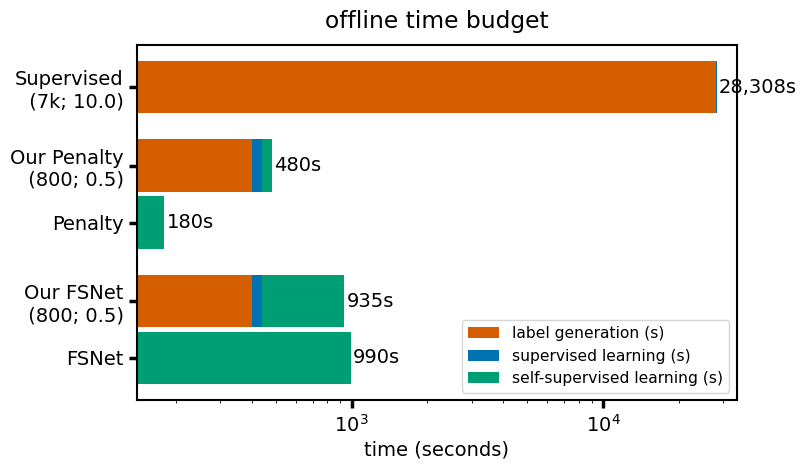

In [13]:
import numpy as np
import matplotlib.pyplot as plt

BASE_FONT_SIZE = 14
BASE_LINEWIDTH = 2.5

def plot_time_budget_two_groups_horizontal():
    # -----------------------------
    # Data (seconds): 2 groups
    # -----------------------------
    groups = {
        "SL": {
            "methods": [
                "Supervised\n (7k; 10.0)",
            ],
            "label generation": np.array([28118], dtype=float),
            "supervised learning":         np.array([190], dtype=float),
            "self-supervised learning":        np.array([0], dtype=float),
        },
        "Soft SSL": {
            "methods": [
                "Penalty",
                "Our Penalty\n (800; 0.5)",
            ],
            "label generation": np.array([0, 400], dtype=float),
            "supervised learning":         np.array([0,   40], dtype=float),
            "self-supervised learning":        np.array([180,     40], dtype=float),
        },
        "Hard SSL": {
            "methods": [
                "FSNet",
                "Our FSNet\n (800; 0.5)",
            ],
            "label generation": np.array([0,   400], dtype=float),
            "supervised learning":         np.array([0,  40], dtype=float),
            "self-supervised learning":        np.array([990, 495], dtype=float),
        },
    }

    # -----------------------------
    # Desired plotting order
    # -----------------------------
    GROUP_ORDER = [
        "Hard SSL",
        "Soft SSL",
        "SL",
    ]

    METHOD_ORDER = {
        "SL": [
            "Supervised\n (7k; 10.0)",
        ],
        "Soft SSL": [
            "Penalty",
            "Our Penalty\n (800; 0.5)",
        ],
        "Hard SSL": [
            "FSNet",
            "Our FSNet\n (800; 0.5)",
        ],
    }

    # Reorder groups and methods (keeps arrays aligned)
    groups_ordered = {}
    for gname in GROUP_ORDER:
        g = groups[gname]

        # build index permutation for the desired method order
        desired = METHOD_ORDER.get(gname, g["methods"])
        idx = [g["methods"].index(m) for m in desired]

        groups_ordered[gname] = {
            "methods": desired,
            "label generation": g["label generation"][idx],
            "supervised learning": g["supervised learning"][idx],
            "self-supervised learning": g["self-supervised learning"][idx],
        }

    groups = groups_ordered

    components = ["label generation", "supervised learning", "self-supervised learning"]  # stack order
    COLORS = {
        "label generation": "#D55E00",
        "supervised learning": "#0072B2",
        "self-supervised learning": "#009E73",
    }

    # -----------------------------
    # Layout: tighter bars within group
    # -----------------------------
    bar_h = 0.72
    dy = 0.78          # spacing between bars *within* a group
    group_gap = 0.3    # spacing *between* groups

    y_positions = []
    y_labels = []
    group_centers = []
    group_ranges = []

    y = 0.0
    for gname, g in groups.items():
        start_y = y
        for m in g["methods"]:
            y_positions.append(y)
            y_labels.append(m)
            y += dy
        end_y = y - dy
        group_centers.append(((start_y + end_y) / 2.0, gname))
        group_ranges.append((start_y - bar_h / 2, end_y + bar_h / 2))
        y += group_gap

    y_positions = np.array(y_positions, dtype=float)

    # Concatenate values in the same order as y_labels
    gen = np.concatenate([groups[g]["label generation"] for g in groups], axis=0)
    sl  = np.concatenate([groups[g]["supervised learning"]         for g in groups], axis=0)
    ssl = np.concatenate([groups[g]["self-supervised learning"]        for g in groups], axis=0)

    stacks = {"label generation": gen, "supervised learning": sl, "self-supervised learning": ssl}
    totals = gen + sl + ssl

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10.0, 4.8))

    left = np.zeros_like(y_positions, dtype=float)
    for comp in components:
        vals = stacks[comp]
        ax.barh(
            y_positions,
            vals,
            height=bar_h,
            left=left,
            label=f"{comp} (s)",
            linewidth=BASE_LINEWIDTH,
            facecolor=COLORS[comp],
            # edgecolor="black",
        )
        left = left + vals

    # Total annotations (to the right of each bar)
    for yi, t in zip(y_positions, totals):
        if t <= 0:
            continue
        ax.text(
            t * 1.02,
            yi,
            f"{t:,.0f}s",
            va="center",
            ha="left",
            fontsize=BASE_FONT_SIZE,
        )

    # Group labels on the left (outside axis a bit)
    # Place them at x = left limit / 2 in log space is tricky; instead, use axes coordinates.
    # for yc, name in group_centers:
    #     ax.text(
    #         -0.02, yc,
    #         name,
    #         transform=ax.get_yaxis_transform(),  # x in axes coords, y in data coords
    #         ha="right",
    #         va="center",
    #         fontsize=BASE_FONT_SIZE,
    #     )

    # Optional: subtle separators between groups
    # Draw a horizontal line after the first group
    # if len(group_ranges) >= 2:
    #     sep_y = (group_ranges[0][1] + group_ranges[1][0]) / 2
    #     ax.axhline(sep_y, linewidth=BASE_LINEWIDTH, alpha=0.35,
    #             color="gray", linestyle="--")


    # -----------------------------
    # Formatting
    # -----------------------------
    ax.set_title("offline time budget", fontsize=BASE_FONT_SIZE * 1.2, pad=12)
    ax.set_xlabel("time (seconds)", fontsize=BASE_FONT_SIZE)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=BASE_FONT_SIZE)
    ax.tick_params(axis="both", labelsize=BASE_FONT_SIZE, width=BASE_LINEWIDTH, length=6, color='black')

    for spine in ax.spines.values():
        spine.set_linewidth(BASE_LINEWIDTH-1)
        spine.set_color('black')


    # Log x-axis to handle 10^2..10^4+ range cleanly
    ax.set_xscale("log")
    # ax.grid(True, which="both", axis="x", linewidth=0.6, alpha=0.35)
    ax.legend(fontsize=BASE_FONT_SIZE * 0.8)

    # Log-scale limits: avoid clipping tiny bars; ignore zeros safely
    # min_pos = np.min(totals[totals > 0])
    ax.set_xlim(right=np.max(totals) * 1.2)

    ax.set_facecolor("white")
    # ax.locator_params(axis='x', nbins=4)

    # Make room for group labels on the left
    fig.tight_layout()
    plt.subplots_adjust(left=0.33)

    plt.show()


if __name__ == "__main__":
    plot_time_budget_two_groups_horizontal()
